# Predicting Airline Route Profitability: XGBoost and Decision Tree
**COM3032/COMM074 | Joel Jolly**

This notebook builds and evaluates two classification models for predicting whether an airline route will turn a profit or run at a loss. The primary model is **XGBoost**, a gradient boosting algorithm that consistently performs well on structured tabular data. The **Decision Tree** is the independently tuned comparison model, tuned separately so the comparison is fair.

Both models are trained on unscaled data. Tree-based algorithms split on individual feature thresholds, so the absolute scale of a feature has no bearing on how splits are chosen or what predictions get made.

---

### Contents

| Section | Notebook Sections | What happens |
|---------|------------------|--------------|
| **Setup** | S1 to S3 | Loads all libraries, reads the preprocessed train/val/test splits, and defines the shared evaluation and visualisation functions used throughout. |
| **Algorithm Rationale** | S4 | Explains why XGBoost was chosen as the primary model, covering sequential boosting, built-in regularisation, class imbalance handling and the stochastic parameters that reduce variance. |
| **XGBoost Baseline** | S5 | Trains a 100-tree XGBoost with scale_pos_weight set to the class ratio, establishing an untuned reference point and an initial overfitting gap to improve on. |
| **Logloss Curve** | S6 | Tracks training and validation logloss across 200 boosting rounds to assess convergence and identify whether more trees would help or hurt. |
| **RandomizedSearchCV Tuning** | S7 | Searches 30 random combinations across n_estimators, max_depth, learning_rate, subsample, colsample_bytree, regularisation terms and scale_pos_weight, scored on ROC-AUC. |
| **Tuned Model Validation** | S8 | Evaluates the best model on the validation set and compares the overfitting gap against the baseline to confirm regularisation is working. |
| **Feature Importance: Gain** | S9 | Plots the top 15 features by average gain across all trees, showing which route characteristics the model relies on most. |
| **Feature Importance: Permutation** | S9b | Measures how much test-set F1 drops when each feature is shuffled, giving a held-out view of genuine predictive value rather than training fit. |
| **Cross-Validation** | S10 | Runs 5-fold stratified cross-validation on the tuned model to check consistency across different subsets of the training data. |
| **Test Set Evaluation** | S11 | Final evaluation on the held-out test set, with confusion matrix and ROC curve saved for the business report. |
| **Enhanced Metrics and Threshold Sweep** | S12 | Full enhanced metrics including MCC, TNR, FPR and financial cost, followed by a threshold sweep showing how precision, recall, F1 and total cost shift as the decision boundary moves. |
| **Decision Tree** | S13 to S18b | Covers rationale, default pre-tuning model, GridSearchCV tuning, tree visualisation, test set evaluation, enhanced metrics, threshold sweep and learning curve. Independently tuned to serve as a fair comparison point for XGBoost. |
| **Model Comparison** | S19 | XGBoost and Decision Tree results side by side on all key metrics, exported for the group final notebook. |
| **Business Implications** | S20 | Practical interpretation of the results in the context of route planning and revenue management decisions. |
| **Saving Outputs** | S21 | Exports the comparison CSV, results JSON and both serialised models for use in the group summary notebook. |

---

### Evaluation Metrics

The table below explains each metric used throughout this notebook. F1-Score is the primary metric because it balances both types of misclassification, which matters here given the financial consequences of getting a prediction wrong in either direction.

| Metric | What it measures |
|--------|-----------------|
| F1-Score | Harmonic mean of precision and recall. Primary metric for this task. |
| ROC-AUC | How well the model ranks routes across all possible thresholds. Used for cross-model comparison. |
| MCC | Matthews Correlation Coefficient. Accounts for all four cells of the confusion matrix and is more informative than accuracy on imbalanced data. |
| TPR / Recall | The share of genuinely profitable routes that the model correctly identifies. |
| TNR | The share of genuinely loss-making routes that the model correctly filters out. |
| FPR | False approval rate: routes that will lose money but are flagged as profitable. |
| Overfit Gap | Training F1 minus test F1. A gap below 0.05 suggests a solid fit. |

## 1. Imports and Environment Setup

This section loads all required libraries. Beyond a standard scikit-learn setup, the `xgboost` package is needed for the primary model.

Path configuration is handled here so that all data reads and figure writes point to the correct shared directories, regardless of where the notebook is opened. Output figures are saved into a `figures/` subfolder within the member directory.

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV,
                                     StratifiedKFold, cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)

print('Libraries loaded.')

Libraries loaded.


## 2. Loading the Preprocessed Data

The training, validation, and test splits are loaded from CSV files produced during the shared preprocessing stage. No feature scaling is applied at this point, nor is it needed. Both XGBoost and Decision Tree work by finding the best threshold to split on at each node, so the magnitude of feature values does not affect their behaviour.

A few constants are fixed here too. `RANDOM_STATE = 42` is applied to every random operation throughout the notebook to keep results fully reproducible. The cost parameters `FP_COST` and `FN_COST` are set to reflect realistic business consequences: keeping an unprofitable route running costs approximately £42,000 per quarter, while incorrectly retiring a profitable one foregoes around £30,000 in revenue. These figures are used later when the threshold sweep plots total financial cost against the decision boundary.

A quick class balance check confirms the approximate 64/36 split between profitable and loss-making routes across all three splits. This imbalance is handled directly in both models rather than being left to chance.

In [5]:
from pathlib import Path

RANDOM_STATE = 42
MEMBER       = 'xgb_joel'
# FP_COST: estimated quarterly operating cost of maintaining one unprofitable route
# FN_COST: estimated foregone revenue from incorrectly retiring a profitable route
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR / "figures"
MEMBER_DIR.mkdir(parents=True, exist_ok=True)


X_train = pd.read_csv(PROC / "X_train.csv")
X_val   = pd.read_csv(PROC / "X_val.csv")
X_test  = pd.read_csv(PROC / "X_test.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Train: (11997, 40), Val: (1500, 40), Test: (1500, 40)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## 3. Shared Utility Functions

This section defines the evaluation and visualisation functions used throughout the notebook. The same suite is shared across all five group members so that every model is measured identically and results slot cleanly into the group summary notebook.

**evaluate** is a lightweight helper that returns the six core metrics as a dictionary. It is used for quick sanity checks during development.

**evaluate_enhanced** is the full evaluation suite. On top of the standard metrics it computes MCC, TNR, FPR, a financial cost estimate based on the false positive count, and an overfitting gap label that classifies the model as underfitting, a good fit, borderline, or memorising.

**plot_confusion_matrix** produces a labelled heatmap using the actual class names (Loss-Making and Profitable) rather than generic 0 and 1.

**plot_roc** draws the ROC curve with the AUC value in the legend. A colour argument is accepted so XGBoost and Decision Tree curves can be distinguished when plotted together.

**plot_learning_curve** runs stratified k-fold cross-validation at increasing proportions of the training set and plots how training and validation F1 evolve. This helps identify whether the model is data-hungry or has already levelled off.

**threshold_sweep** moves the decision threshold from 0.10 to 0.90 in steps and records how precision, recall, F1, and total financial cost change at each point. Two subplots are generated: one showing the metric tradeoffs across thresholds, and one showing the cost curve, each with a vertical marker at the optimal point.

In [3]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < -0.05 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## 4. Why XGBoost Was Chosen as the Primary Model

XGBoost builds trees one at a time, where each new tree is trained on the residual errors left by the current ensemble. This sequential correction process gradually reduces both bias and variance in a controlled way, which tends to produce better generalisation than building all trees independently as Random Forest does.

Several properties make it a good fit for this route profitability problem.

The built-in regularisation terms, `reg_alpha` (L1) and `reg_lambda` (L2), penalise model complexity directly within the objective function. Overfitting can therefore be controlled without needing to restrict tree depth as the sole lever, which gives considerably more flexibility during hyperparameter tuning.

`scale_pos_weight` handles the 64/36 class imbalance by amplifying the gradient contribution of profitable route examples during training. This is mathematically equivalent to upweighting minority-class errors without duplicating samples, keeping training efficient.

The `subsample` and `colsample_bytree` parameters introduce row-level and feature-level randomness at each boosting round. This stochastic element reduces variance in a manner similar to the bagging used in Random Forest, and it tends to improve generalisation on structured numerical data.

One real limitation of XGBoost is the size of its hyperparameter space. A full grid search across every combination would be computationally impractical, so RandomizedSearchCV is used instead to sample the space efficiently within a reasonable time budget.

## 5. XGBoost Baseline

Before any tuning takes place, a baseline XGBoost model is trained to establish a reference point. This uses 100 trees and sets `scale_pos_weight` to the ratio of negative to positive training examples, which directly compensates for the class imbalance during gradient updates.

The baseline gives a clear view of what the algorithm achieves out of the box and provides the overfitting gap figure that tuning will later aim to reduce.

In [4]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_ratio = neg_count / pos_count
print(f"Negative: {neg_count}, Positive: {pos_count}, scale_pos_weight: {class_ratio:.4f}")

X_tr, X_va, X_te = X_train, X_val, X_test

xgb_base = XGBClassifier(n_estimators=100, scale_pos_weight=class_ratio,
                          eval_metric='logloss', verbosity=0,
                          random_state=RANDOM_STATE, use_label_encoder=False)
xgb_base.fit(X_tr, y_train)

y_val_pred_b = xgb_base.predict(X_va)
y_val_prob_b = xgb_base.predict_proba(X_va)[:, 1]
y_tr_pred_b  = xgb_base.predict(X_tr)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val,   y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline XGBoost — Validation ===')
for k, v in evaluate('XGB-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

Negative: 4358, Positive: 7639, scale_pos_weight: 0.5705
=== Baseline XGBoost — Validation ===
  Model       : XGB-baseline
  Accuracy    : 0.914
  Precision   : 0.9422
  Recall      : 0.9215
  F1_Score    : 0.9317
  ROC_AUC     : 0.9756
  Train F1    : 0.9950
  Overfit Gap : 0.0633


## 6. Logloss Curve: Training vs Validation

XGBoost can track a chosen evaluation metric at the end of every boosting round when an `eval_set` is passed during fitting. Here, logloss is tracked on both the training set and the validation set across 200 rounds.

Plotting these two curves together shows how quickly the model converges and whether additional boosting rounds are still adding value. If the validation loss flattens or starts to climb while training loss continues to fall, that is a signal of overfitting and an argument for capping `n_estimators` at an earlier point.

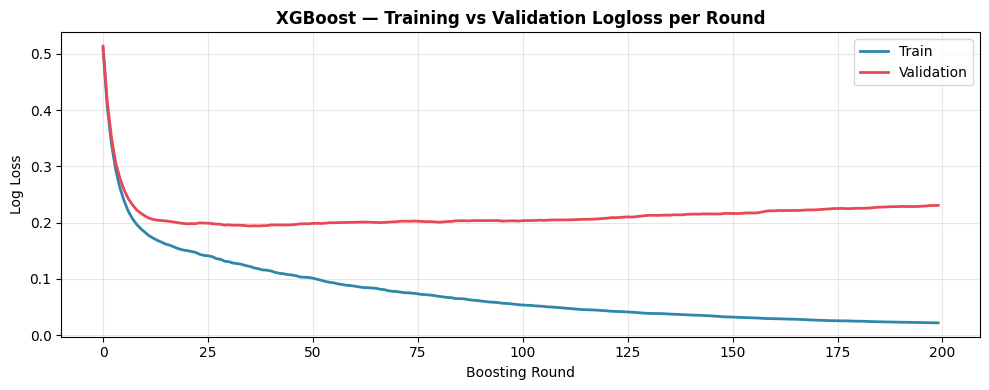

Saved: xgb_logloss_curve_joel.png


In [5]:
eval_model = XGBClassifier(n_estimators=200, scale_pos_weight=class_ratio,
                            eval_metric='logloss', verbosity=0,
                            random_state=RANDOM_STATE, use_label_encoder=False)
eval_model.fit(X_tr, y_train, eval_set=[(X_tr, y_train), (X_va, y_val)], verbose=False)

res = eval_model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
ax.plot(res['validation_0']['logloss'], label='Train', color=C_NEUTRAL, lw=2)
ax.plot(res['validation_1']['logloss'], label='Validation', color=C_LOSS, lw=2)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost — Training vs Validation Logloss per Round', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'xgb_logloss_curve_joel.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_logloss_curve_joel.png')

## 7. Hyperparameter Tuning with RandomizedSearchCV

XGBoost has a large number of hyperparameters that interact in non-obvious ways, so a full GridSearchCV across every combination would be computationally expensive. RandomizedSearchCV is used instead, sampling 30 random combinations from the parameter distributions defined below.

The parameters being searched cover the main levers for controlling model complexity and generalisation:

`n_estimators` controls the number of boosting rounds. `max_depth` limits how deep each individual tree can grow. `learning_rate` scales the contribution of each new tree, with smaller values requiring more trees but often generalising better. `subsample` and `colsample_bytree` introduce stochastic regularisation by randomly selecting a fraction of rows and features at each round. `reg_alpha` and `reg_lambda` apply L1 and L2 penalties to the leaf weights. `scale_pos_weight` is included as a searchable parameter to let the algorithm decide whether explicit class weighting actually helps.

Scoring is done on ROC-AUC across 5 stratified folds, which gives a stable estimate of ranking quality that is less sensitive to the class distribution than raw accuracy.

In [6]:
param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, 9],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'scale_pos_weight' : [class_ratio, 1],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [1, 1.5, 2]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', verbosity=0,
                  random_state=RANDOM_STATE, use_label_encoder=False),
    param_dist, n_iter=30, cv=cv5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
print('Running RandomizedSearchCV (n_iter=30) for XGBoost...')
search.fit(X_tr, y_train)

best_xgb = search.best_estimator_
best_params_xgb = search.best_params_
print(f'Best params : {best_params_xgb}')
print(f'Best CV AUC : {search.best_score_:.4f}')

Running RandomizedSearchCV (n_iter=30) for XGBoost...
Best params : {'subsample': 0.7, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV AUC : 0.9732


### What the Tuning Tells Us

One of the more interesting outcomes from the search is that it selected `scale_pos_weight=1`, meaning no explicit class weighting, despite the 64/36 imbalance in the data. This suggests that XGBoost's combination of stochastic row sampling via `subsample`, L1 regularisation, and a moderate learning rate provides enough robustness to handle the imbalance without needing to amplify minority-class gradients directly. The regularisation parameters appear to be doing the heavy lifting in terms of generalisation, which is reflected in the reduction of the overfitting gap compared to the baseline.

## 8. Evaluating the Tuned Model on the Validation Set

With the best parameters identified, the tuned model is evaluated on the validation set. This gives an honest picture of how well tuning has improved generalisation before the final test set is touched.

The overfitting gap from the baseline is printed alongside the tuned gap so the two can be compared directly. A meaningful reduction in the gap confirms that the regularisation settings selected during the search are working as intended.

In [7]:
y_val_pred = best_xgb.predict(X_va)
y_val_prob = best_xgb.predict_proba(X_va)[:, 1]
y_tr_pred  = best_xgb.predict(X_tr)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned XGBoost — Validation ===')
for k, v in evaluate('XGB-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned XGBoost — Validation ===
  Model       : XGB-tuned
  Accuracy    : 0.912
  Precision   : 0.9327
  Recall      : 0.9288
  F1_Score    : 0.9307
  ROC_AUC     : 0.9757
  Train F1    : 0.9825
  Overfit Gap : 0.0517  (baseline was 0.0633)


## 9. Feature Importance: Gain

XGBoost records how much each feature contributes to splits across all trees in the ensemble. The gain metric measures the average improvement in the objective function each time a feature is used for a split, weighted by the number of observations that pass through it.

Gain is generally preferred over split frequency because it accounts for the quality of the split rather than just how often a feature appears. A feature that is used rarely but always produces a large improvement in purity will score higher on gain than one that is used constantly but achieves little.

The top 15 features are plotted here to give a sense of which route characteristics the model is relying on most heavily.

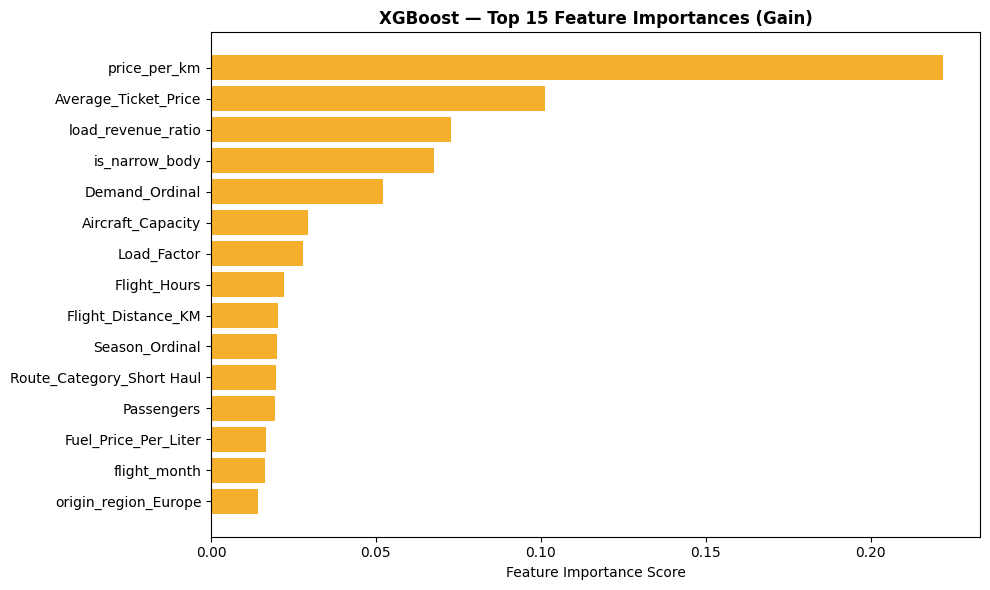

Saved: xgb_feature_importance_joel.png


In [8]:
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': best_xgb.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color='#F6AE2D')
ax.set_title('XGBoost — Top 15 Feature Importances (Gain)', fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'xgb_feature_importance_joel.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_feature_importance_joel.png')

## 9b. Feature Importance: Permutation Method

Gain-based importance has a known limitation: it is measured on the training data, so it can reflect features that the model has overfit to rather than features that genuinely help on unseen data.

Permutation importance addresses this by working on the held-out test set. Each feature is shuffled one at a time, breaking its relationship with the target, and the drop in F1 score is recorded. Features that cause a large drop when shuffled are the ones the model genuinely depends on for correct predictions. Features that can be shuffled with little effect are not adding much real signal.

The error bars show the standard deviation across 10 repeated permutations, which gives a sense of how stable each importance estimate is.

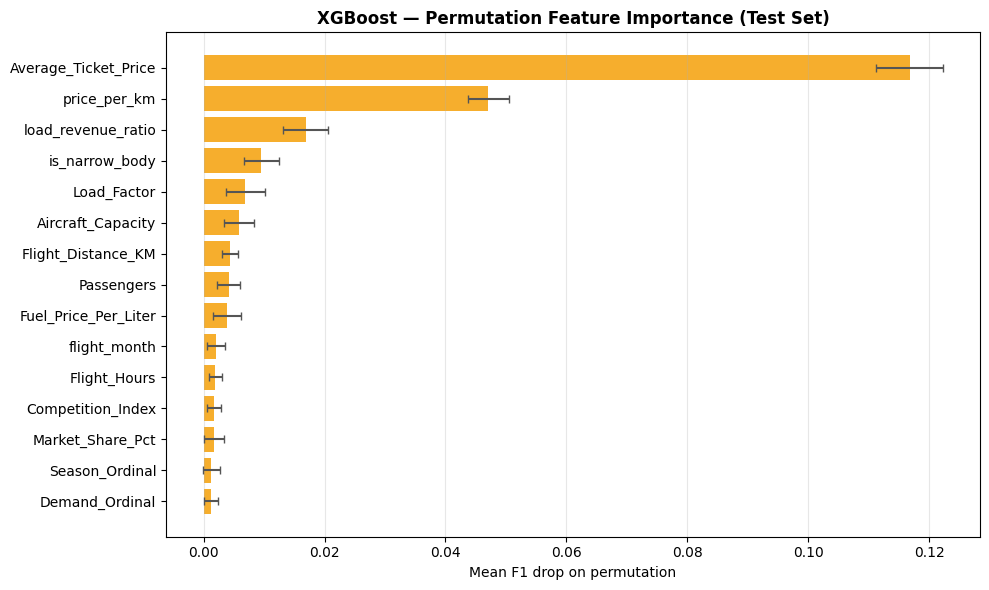

Saved: perm_importance_joel.png


In [9]:
from sklearn.inspection import permutation_importance

perm_res = permutation_importance(
    best_xgb, X_te, y_test,
    n_repeats=10, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)
perm_df_xgb = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_res.importances_mean,
    'Std'       : perm_res.importances_std
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(perm_df_xgb['Feature'][::-1], perm_df_xgb['Importance'][::-1],
        xerr=perm_df_xgb['Std'][::-1], color='#F6AE2D', ecolor='#555', capsize=3)
ax.set_xlabel('Mean F1 drop on permutation')
ax.set_title('XGBoost — Permutation Feature Importance (Test Set)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'perm_importance_joel.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: perm_importance_joel.png')

## 10. Cross-Validation: Stability Check

A single train/test split can give a misleading picture of model performance if that particular split happens to be easy or unusually hard. Five-fold stratified cross-validation addresses this by training and evaluating on five different splits of the training data and averaging the results.

The mean F1 across folds is the headline figure, and the standard deviation tells you how much performance varies depending on which data the model sees. A low standard deviation suggests the model is consistent and not overly sensitive to the specific examples it is trained on.

In [10]:
cv_scores = cross_val_score(best_xgb, X_tr, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.9274 ± 0.0057
Per-fold F1 : [0.9337 0.9205 0.9347 0.9244 0.9237]


## 11. Final Evaluation on the Test Set

The test set has been held back throughout the entire modelling process and is only used here. Evaluating on data the model has never influenced in any way gives the most honest estimate of how it would perform on genuinely new routes.

The confusion matrix and ROC curve are both saved as figures for inclusion in the business report.

=== Tuned XGBoost — Test Set ===
  Model       : XGB-test
  Accuracy    : 0.916
  Precision   : 0.9313
  Recall      : 0.9372
  F1_Score    : 0.9342
  ROC_AUC     : 0.9774

              precision    recall  f1-score   support

 Loss-Making       0.89      0.88      0.88       545
  Profitable       0.93      0.94      0.93       955

    accuracy                           0.92      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.92      0.92      0.92      1500



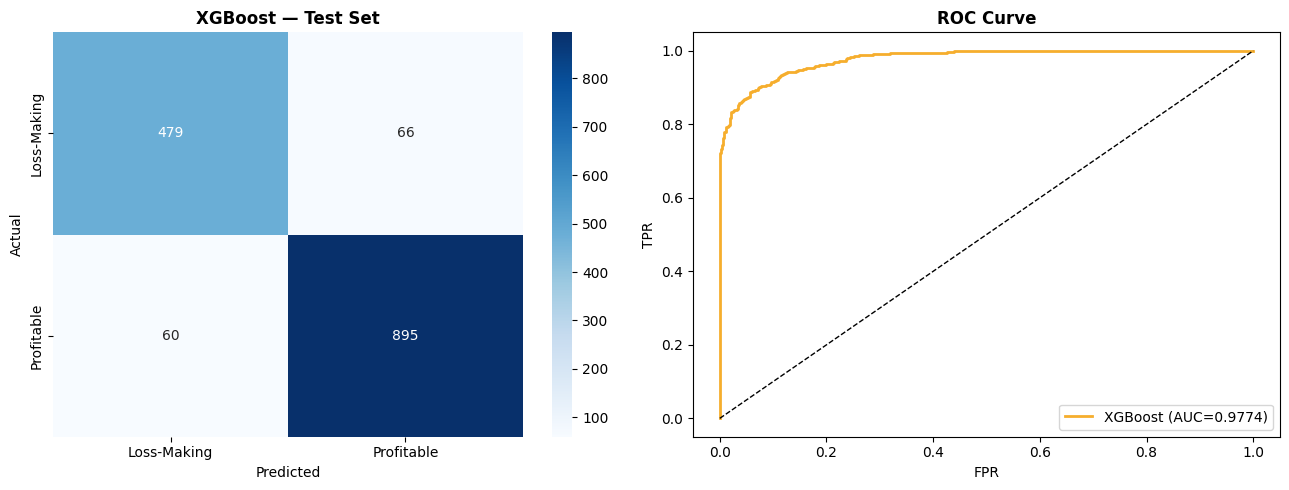

Saved: xgb_cm_roc_test_joel.png


In [11]:
y_test_pred = best_xgb.predict(X_te)
y_test_prob = best_xgb.predict_proba(X_te)[:, 1]

print('=== Tuned XGBoost — Test Set ===')
for k, v in evaluate('XGB-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'XGBoost — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'XGBoost', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'xgb_cm_roc_test_joel.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_cm_roc_test_joel.png')

## 12. Enhanced Metrics and Threshold Sweep

This section runs the full enhanced evaluation on the test set and then sweeps the decision threshold to understand how performance and financial cost change depending on where the classification boundary is drawn.

By default, a predicted probability above 0.5 is classified as profitable. But that default is not always optimal. If the cost of a false positive (approving a loss-making route) is higher than the cost of a false negative (rejecting a profitable one), it may make sense to raise the threshold and accept lower recall in exchange for better precision. The sweep plots both the metric tradeoffs and the total financial cost across all thresholds, with markers at the point that maximises F1 and the point that minimises cost.

Financial parameters used here: FP cost = £42,000 per route per quarter, FN cost = £30,000 per route per quarter.

In [12]:
xgb_metrics = evaluate_enhanced('XGBoost (Tuned)', best_xgb, X_tr, y_train, X_te, y_test)

=== Enhanced Evaluation: XGBoost (Tuned) ===
  Accuracy  : 0.9160
  Precision : 0.9313  (FP count: 66, FP cost: £2,772,000)
  Recall    : 0.9372  (FN count: 60)
  F1-Score  : 0.9342
  ROC-AUC   : 0.9774
  MCC       : 0.8180  (genuine discriminative ability)
  TNR       : 0.8789
  FPR       : 0.1211
  Train F1  : 0.9825
  Test  F1  : 0.9342
  Overfit Gap: 0.0482  [good fit]


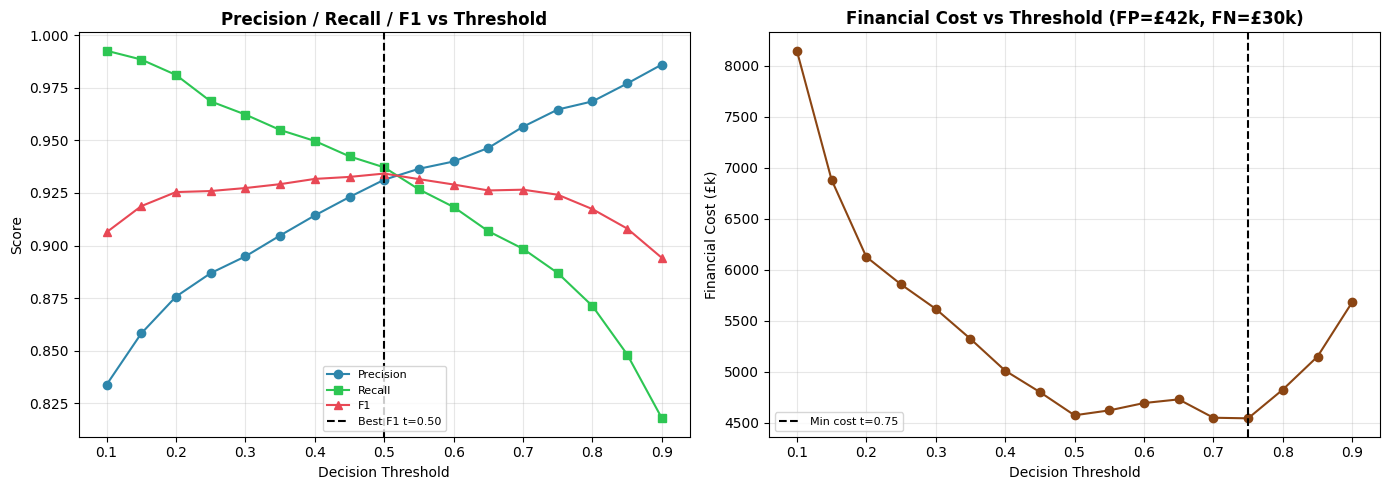

Threshold sweep: Best F1 at t=0.50, Min cost at t=0.75
Saved: xgb_threshold_sweep_joel.png


In [13]:
threshold_sweep(best_xgb, X_te, y_test,
                os.path.join(FIG_DIR, 'xgb_threshold_sweep_joel.png'))

## 13. The Decision Tree: Algorithm Rationale

The Decision Tree is the independently tuned comparison model for this notebook. It is independently tuned rather than left at default settings, which makes it a more meaningful comparison point. A default untuned tree almost always overfits severely, which would make XGBoost look better than it might actually be by comparison.

A single decision tree works by recursively splitting the data on the feature threshold that best separates the two classes at each node. The result is a set of if-then rules that can be read directly from the visualised tree, making it one of the most interpretable models available. Each internal node corresponds to a routing condition such as load factor falling below a certain value or price per kilometre exceeding a threshold.

For this notebook, the tree is tuned using entropy as the splitting criterion and depths up to 11 are explored. Class balancing is switched off during the grid search, which lets the tree follow the natural class frequencies in the data. This setup is deliberately different from the default configuration used by other group members, allowing this notebook to explore whether unconstrained entropy-based splitting adds anything compared to a class-balanced approach. The key principle is that each member's primary model is compared directly against their own independently tuned Decision Tree, isolating the contribution of the algorithm itself.

Key properties of the Decision Tree used here:

- **Interpretable** by design. The full tree structure can be visualised and explained to non-technical stakeholders without needing to open the codebase.
- **Scale-invariant**, consistent with all tree-based models in the group.
- **Depth-controlled** via GridSearchCV to prevent the tree from memorising training examples.
- **Minimum leaf size enforced** to stop the tree from creating trivially small terminal nodes that do not generalise.

## 14. Decision Tree — Default (Pre-Tuning)

A default Decision Tree with no depth limit is trained first to establish how badly an unconstrained tree overfits. This default model gives the overfitting gap figure that motivates the grid search in the next section.

`class_weight='balanced'` is applied at this stage so the baseline tree at least acknowledges the class imbalance, even if it lacks any other form of regularisation.

In [4]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Default Decision Tree — Validation ===')
for k, v in evaluate('DT-default', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Default Decision Tree — Validation ===
  Model       : DT-default
  Accuracy    : 0.8787
  Precision   : 0.9005
  Recall      : 0.9099
  F1_Score    : 0.9052
  ROC_AUC     : 0.8669
  Train F1    : 1.0000
  Overfit Gap : 0.0948


## 15. Tuning the Decision Tree with GridSearchCV

The Decision Tree is tuned using a full grid search rather than a randomised one. This is practical here because the parameter space is much smaller than XGBoost's, meaning every combination can be evaluated without a prohibitive compute cost.

The search covers four dimensions. `max_depth` is searched across values of 5, 7, 9, and 11, testing how much the depth limit affects the balance between expressiveness and overfitting. `min_samples_split` controls the minimum number of samples a node must contain before it is eligible to be split further, acting as an early stopping rule for growth. `min_samples_leaf` sets the minimum number of samples required in each leaf node, which prevents the tree from creating very specific rules that only apply to a handful of training examples. The `criterion` is fixed to entropy throughout, which measures impurity using information gain rather than the Gini index.

All combinations are evaluated using 5-fold stratified cross-validation scored on ROC-AUC, matching the evaluation approach used for XGBoost.

In [15]:
param_grid_dt = {
    'max_depth'        : [5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [5, 10, 15],
    'criterion'        : ['entropy'],
    'class_weight'     : [None]
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best CV AUC : 0.9593


### What the Tuning Tells Us

The entropy criterion without class balancing allows the tree to make splits that reflect the natural distribution of the training data, which tends to favour precision over recall balance. Allowing depths up to 11 gives the tree enough room to capture more complex relationships between route features, while the minimum leaf size of 5 or more prevents it from chasing noise in very small subsets of the data. The final tuned configuration represents the best depth and regularisation combination the grid search found, and it provides the Decision Tree result that gets compared against XGBoost at the end of the notebook.

## 16. Visualising the Tuned Tree

The top three levels of the tuned Decision Tree are plotted here. Restricting the visualisation to three levels keeps it readable while still revealing the primary split conditions the model is using.

Each node shows the feature and threshold being tested, the impurity score, the number of samples reaching that node, and which class the node would predict if it were a leaf. The colour fill indicates the dominant class at each node, with deeper colour showing higher confidence. Reading the tree from the root downwards gives a direct view of the routing logic the model has learnt.

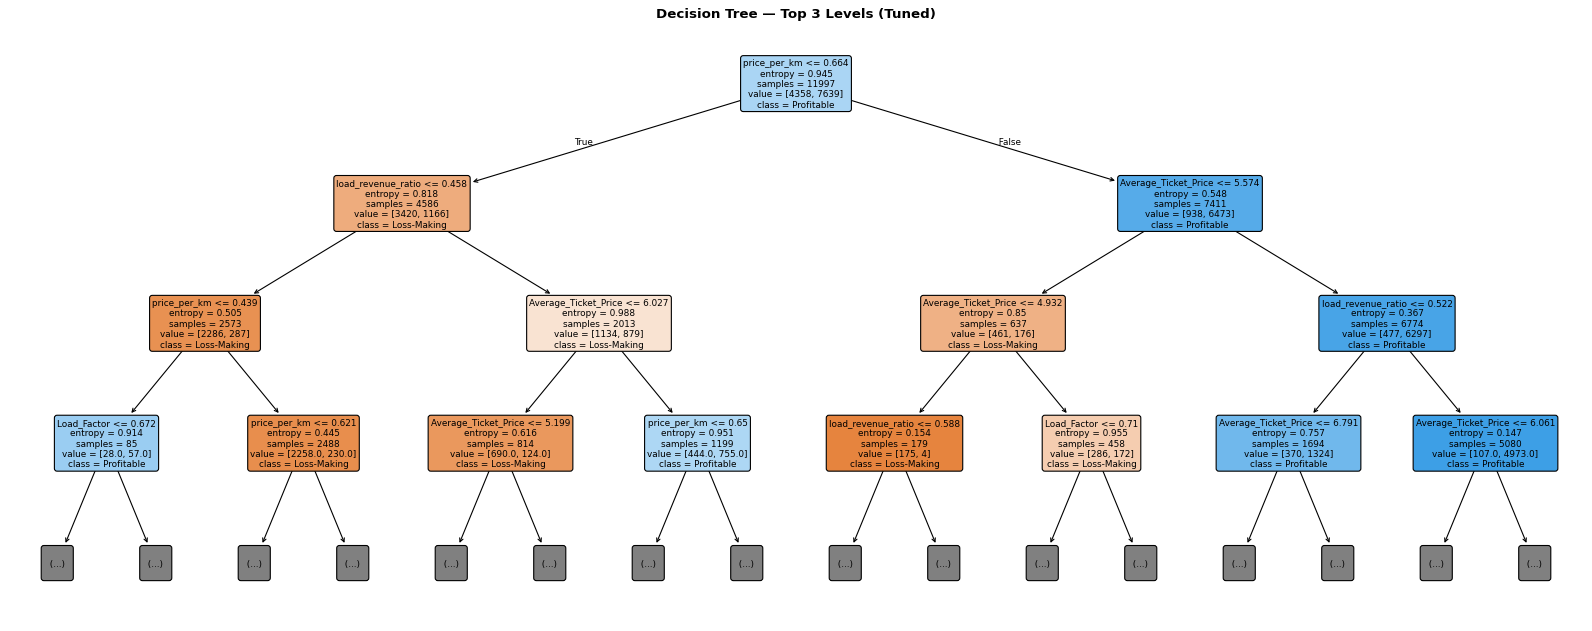

Saved: dt_tree_viz_joel.png


In [16]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_joel.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_joel.png')

## 17. Decision Tree Test Set Evaluation

The tuned Decision Tree is evaluated on the held-out test set. The same metrics computed for XGBoost are reported here so the two models can be compared directly in the summary table at the end of the notebook.

The confusion matrix and ROC curve are both saved as figures.

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.9013
  Precision   : 0.927
  Recall      : 0.9173
  F1_Score    : 0.9221
  ROC_AUC     : 0.9581

              precision    recall  f1-score   support

 Loss-Making       0.86      0.87      0.87       545
  Profitable       0.93      0.92      0.92       955

    accuracy                           0.90      1500
   macro avg       0.89      0.90      0.89      1500
weighted avg       0.90      0.90      0.90      1500



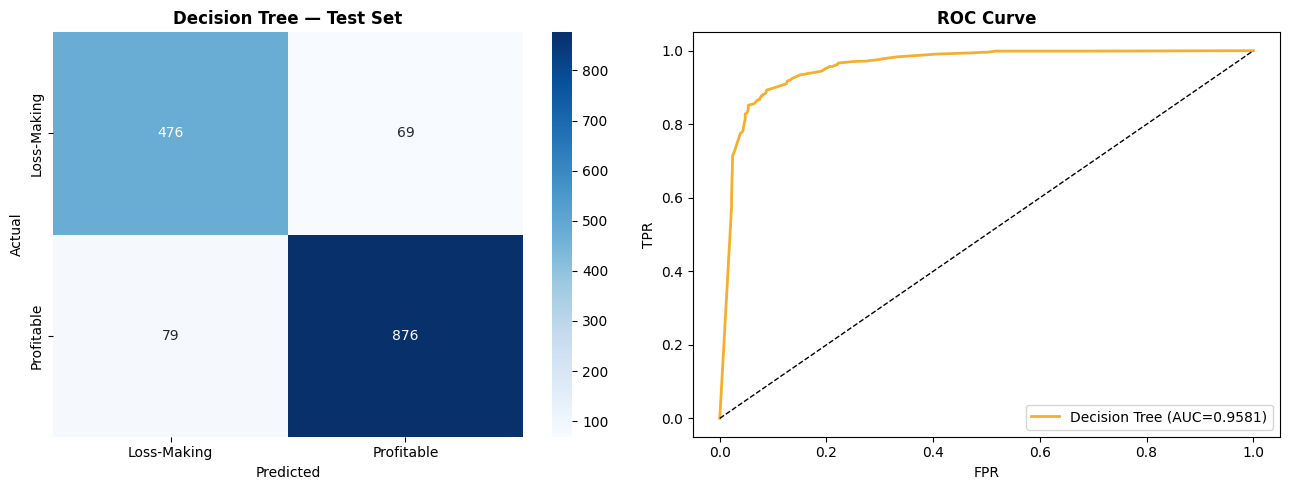

Saved: dt_cm_roc_test_joel.png


In [17]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_joel.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_joel.png')

## 18. Decision Tree: Enhanced Metrics

The enhanced evaluation suite is run on the Decision Tree to produce the full set of metrics including MCC, TNR, FPR, financial cost, and the overfitting gap label. These figures feed into the comparison table in Section 19.

In [18]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.9013
  Precision : 0.9270  (FP count: 69, FP cost: £2,898,000)
  Recall    : 0.9173  (FN count: 79)
  F1-Score  : 0.9221
  ROC-AUC   : 0.9581
  MCC       : 0.7877  (genuine discriminative ability)
  TNR       : 0.8734
  FPR       : 0.1266
  Train F1  : 0.9311
  Test  F1  : 0.9221
  Overfit Gap: 0.0090  [good fit]


## 18b. Decision Tree: Threshold Sweep and Learning Curve

The same threshold sweep run on XGBoost is repeated here for the Decision Tree. This allows a direct visual comparison of how the two models behave as the decision boundary shifts, and which one maintains better precision-recall balance or lower financial cost at a given threshold.

The learning curve is also generated here. This plots validation F1 against increasing amounts of training data and helps answer whether the model is limited by the amount of data available or whether it has already reached its capacity given the current feature set. If the training and validation curves converge at a relatively low F1, adding more data is unlikely to help much and the model architecture itself may need revisiting.

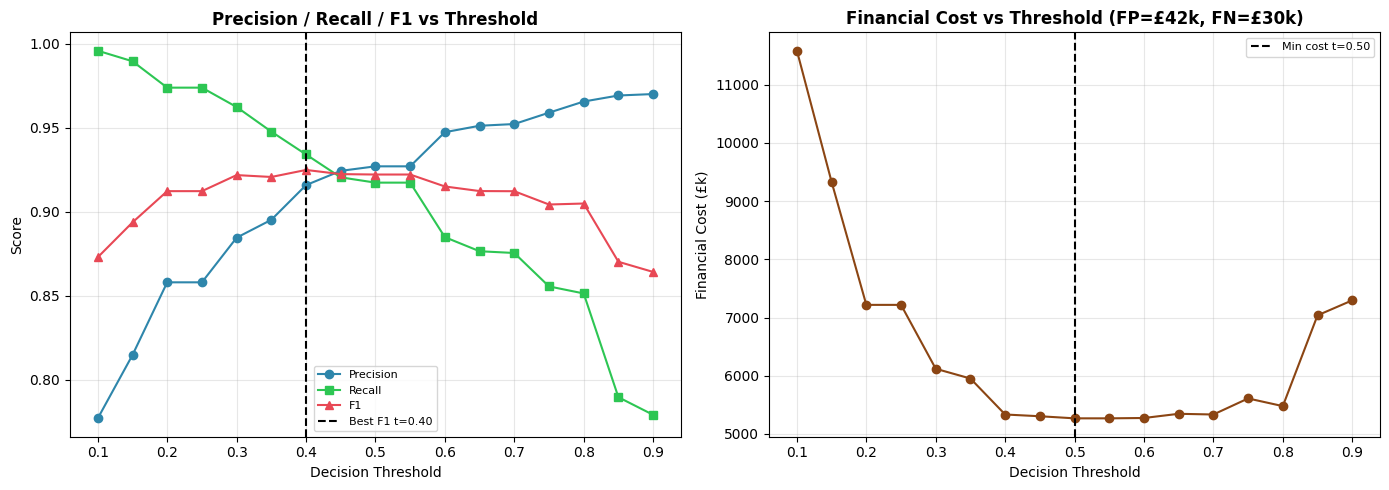

Threshold sweep: Best F1 at t=0.40, Min cost at t=0.50
Saved: dt_threshold_sweep_joel.png
Saved: dt_threshold_sweep_joel.png


In [19]:
threshold_sweep(best_dt, X_te_dt, y_test,
                os.path.join(FIG_DIR, 'dt_threshold_sweep_joel.png'))
print('Saved: dt_threshold_sweep_joel.png')

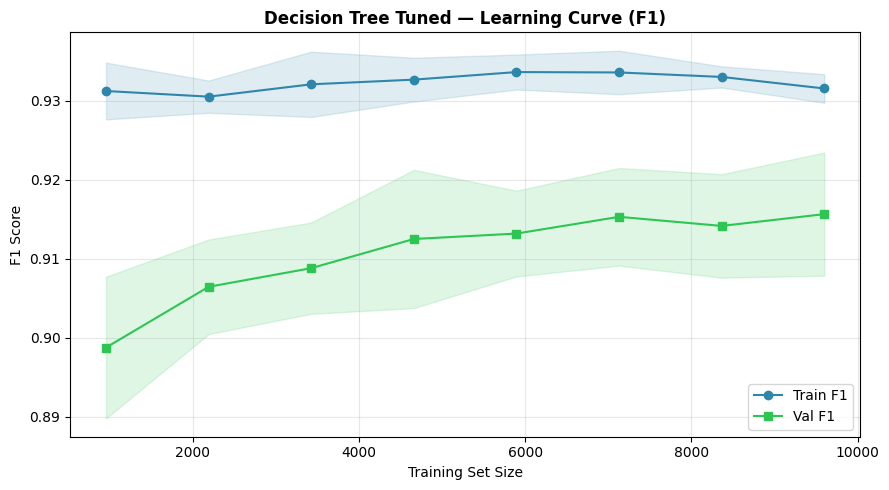

Saved: dt_tuned_learning_curve_joel.png
Saved: dt_tuned_learning_curve_joel.png


In [20]:
plot_learning_curve(
    best_dt, X_tr_dt, y_train,
    'Decision Tree Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'dt_tuned_learning_curve_joel.png')
)
print('Saved: dt_tuned_learning_curve_joel.png')

## 19. XGBoost vs Decision Tree: Summary Comparison

Both models are brought together in a single comparison table covering all key metrics on the test set. This table is exported and feeds into the group final notebook where all five models are compared side by side.

The comparison covers predictive performance metrics, the financial cost of false positives, and the overfitting gap, giving a rounded view of which model performs better and where the tradeoffs lie.

In [21]:
compare = pd.DataFrame([xgb_metrics, dt_metrics])
print('\n=== Test Set Comparison: XGBoost vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: XGBoost vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
      XGBoost (Tuned)    0.9160     0.9313  0.9372    0.9342   0.9774 0.8180 0.8789 0.1211      2772000       0.0482      good fit
Decision Tree (Tuned)    0.9013     0.9270  0.9173    0.9221   0.9581 0.7877 0.8734 0.1266      2898000       0.0090      good fit


## 20. Business Implications

This section draws out what the modelling results mean in practical terms for route planning decisions.

XGBoost's sequential boosting process allows it to pick up on interactions between features such as load factor, season, and competitive pressure that a single tree tends to miss. These interactions are often exactly the kind of nuanced signal that separates profitable routes from marginal ones.

The feature importance analysis points to a small number of route characteristics that consistently drive predictions. Features that rank highly on both gain-based and permutation-based importance are the most reliable indicators of profitability, and they are worth examining closely when making route decisions.

The threshold sweep demonstrates that the default 0.5 decision boundary is not necessarily the best choice from a financial perspective. Shifting the threshold to minimise total cost rather than maximise F1 can reduce the financial exposure from incorrectly approved routes, depending on the relative costs assigned to each type of error.

A model of this type is practical to deploy in a real-time route scoring context. Generating a prediction for a new route takes milliseconds, making it suitable for integration into existing planning or revenue management tooling.

## 21. Saving Outputs

The comparison table is saved as a CSV, and the full results dictionary is written out as a JSON file. The JSON file includes validation and test metrics for both models, the best hyperparameters found by each search, and the full enhanced metric dictionaries. This gives the group notebook everything it needs to build the cross-member comparison without re-running any training code.

In [22]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'xgb_dt_joel.csv'), index=False)
print('Saved: xgb_dt_joel.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'XGBoost',
    'notebook'            : '03_Member2',
    'best_params_primary' : best_params_xgb,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('XGB-val',  y_val,  y_val_pred,  y_val_prob),
    'test_metrics_primary': evaluate('XGB-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'xgb_enhanced'        : xgb_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_xgb_joel.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_xgb_joel.json')

with open(os.path.join(MEMBER_DIR, 'best_xgb_joel.pkl'), 'wb') as f:
    pickle.dump(best_xgb, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_joel.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_xgb_joel.pkl, best_dt_joel.pkl')

print('\n=== Final Test Metrics Summary (XGBoost) ===')
for k, v in xgb_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: xgb_dt_joel.csv
Saved: results_xgb_joel.json
Saved: best_xgb_joel.pkl, best_dt_joel.pkl

=== Final Test Metrics Summary (XGBoost) ===
  Model               : XGBoost (Tuned)
  Accuracy            : 0.916
  Precision           : 0.9313
  Recall              : 0.9372
  F1_Score            : 0.9342
  ROC_AUC             : 0.9774
  MCC                 : 0.818
  TNR                 : 0.8789
  FPR                 : 0.1211
  FP_Cost_GBP         : 2772000
  Train_F1            : 0.9825
  Overfit_Gap         : 0.0482
  Overfit_Label       : good fit
